# Bearing Health-State Classification and RUL Prediction

This notebook trains a Random Forest model to predict the Remaining Useful Life (RUL) of bearings using extracted vibration features.

Import Libraries
- Required Python libraries for data handling, model training, evaluation, saving the model, and visualization. 

In [55]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Load Training Feature Data
- The file `train_features.csv` contains the extracted vibration features and the target RUL values.

In [56]:
DATA_PATH = Path("train_features.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape:
(7534, 16)

Columns:
['rms_x', 'peak_x', 'kurtosis_x', 'skew_x', 'std_x', 'crest_x', 'rms_y', 'peak_y', 'kurtosis_y', 'skew_y', 'std_y', 'crest_y', 'time_step', 'total_steps', 'RUL', 'bearing']


,rms_x,peak_x,kurtosis_x,skew_x,std_x,crest_x,rms_y,peak_y,kurtosis_y,skew_y,std_y,crest_y,time_step,total_steps,RUL,bearing
0,0.561746,2.010,-0.131465,-0.004711,0.561735,3.578132,0.435801,1.591,-0.035080,0.002713,0.435797,3.650745,0,2803,2802,Bearing1_1
1,0.535112,1.915,-0.084646,-0.025791,0.535083,3.578687,0.420968,1.666,0.150620,0.077380,0.420967,3.957542,1,2803,2801,Bearing1_1
2,0.531158,1.901,0.033388,-0.005016,0.531142,3.578971,0.425605,1.584,-0.061552,-0.024393,0.425600,3.721758,2,2803,2800,Bearing1_1
3,0.554833,1.910,0.043419,-0.080165,0.554830,3.442476,0.445524,1.600,-0.113319,-0.008190,0.445524,3.591275,3,2803,2799,Bearing1_1
4,0.566652,1.767,-0.185477,-0.034187,0.566646,3.118317,0.423847,1.373,-0.034816,0.081213,0.423731,3.239377,4,2803,2798,Bearing1_1


Inspect Dataset Columns
- This step checks all available columns to identify feature columns, target column, and bearing identifier.

In [57]:
for i, col in enumerate(df.columns):
    print(i, ":", col)

0 : rms_x
1 : peak_x
2 : kurtosis_x
3 : skew_x
4 : std_x
5 : crest_x
6 : rms_y
7 : peak_y
8 : kurtosis_y
9 : skew_y
10 : std_y
11 : crest_y
12 : time_step
13 : total_steps
14 : RUL
15 : bearing


Prepare Features and Target
- The input features are vibration statistics from x and y accelerometer signals.  
- The target variable is `RUL`, and `bearing` is used for grouped splitting.

In [58]:
# Create normalized life progression feature
df["life_fraction"] = df["time_step"] / df["total_steps"]

feature_cols = [
    'rms_x',
    'peak_x',
    'kurtosis_x',
    'skew_x',
    'std_x',
    'crest_x',
    'rms_y',
    'peak_y',
    'kurtosis_y',
    'skew_y',
    'std_y',
    'crest_y',
    'time_step',
    'life_fraction'
]

X = df[feature_cols]

y = df['RUL']

groups = df['bearing']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7534, 14)
Target shape: (7534,)


Train-Test Split by Bearing
- The dataset is split by bearing using `GroupShuffleSplit` to avoid data leakage.  
- This ensures samples from the same bearing are not present in both training and test sets.

In [59]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

Train samples: 3860
Test samples: 3674


Train Random Forest Regressor
- A Random Forest Regressor is trained to predict the Remaining Useful Life.  
- Random Forest is suitable because it works well with tabular features and provides feature importance.

In [60]:
model = RandomForestRegressor(
    n_estimators=100,          # ← Reduced from 500
    max_depth=15,              # ← Reduced from 20
    min_samples_leaf=5,        # ← Increased from 1
    min_samples_split=10,      # ← Increased from 2
    random_state=42,
    n_jobs=-1
)

print("Training model...")

model.fit(X_train, y_train)

print("Training complete!")

Training model...
Training complete!


Generate RUL Predictions
- The trained model predicts RUL values for the held-out test bearings.

In [61]:
y_pred = model.predict(X_test)

print("Predictions complete!")

print(y_pred[:10])

Predictions complete!
[880.91878439 894.44256269 883.20412854 894.26415144 891.1582207
 888.55237133 871.22790235 886.30207069 892.4069157  889.654446  ]


Evaluate Model Performance
- The model is evaluated using RMSE, MAE, and R² score.

In [62]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 885.7197470051052
MAE: 674.4653453396936
R2 Score: -0.14813504398709942


Calculate PHM Score
- The PHM score is an asymmetric metric that penalizes late predictions more strongly than early predictions.

In [63]:
def phm_score(y_true, y_pred):

    score = 0

    for true, pred in zip(y_true, y_pred):

        d = pred - true

        if d < 0:
            score += np.exp(-d / 13) - 1

        else:
            score += np.exp(d / 10) - 1

    return score


score = phm_score(y_test.values, y_pred)

print("PHM Score:", score)

PHM Score: 1.3516120753286864e+65


Estimate Prediction Uncertainty
- Uncertainty is estimated using the standard deviation of predictions across all trees in the Random Forest.

In [64]:
tree_predictions = np.array([
    tree.predict(X_test)
    for tree in model.estimators_
])

prediction_mean = tree_predictions.mean(axis=0)

prediction_std = tree_predictions.std(axis=0)

print("Uncertainty estimation complete!")

print(prediction_std[:10])

Uncertainty estimation complete!
[215.16516362 219.12228824 223.51224292 228.05265094 220.69502139
 228.42777193 211.81477051 227.56575409 236.66633918 235.67555141]


c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X 

Create Results Table

The final results table contains:

- Actual Remaining Useful Life (RUL)
- Predicted RUL
- Prediction uncertainty
- 95% confidence bounds
- Actual health-state class
- Predicted health-state class

This table summarizes the performance of the predictive maintenance model
and converts continuous RUL predictions into practical maintenance categories.

In [65]:
results = df.iloc[test_idx][["bearing", "time_step", "total_steps"]].copy()

results["Actual_RUL"] = y_test.values
results["Predicted_RUL"] = prediction_mean
results["Uncertainty"] = prediction_std
results["Lower_RUL"] = prediction_mean - 1.96 * prediction_std
results["Upper_RUL"] = prediction_mean + 1.96 * prediction_std


def rul_to_health_state(rul):
    if rul > 200:
        return "Non-critical"
    elif rul > 80:
        return "Wear detectable"
    else:
        return "Imminent failure"


results["Actual_Health_State"] = results["Actual_RUL"].apply(rul_to_health_state)
results["Predicted_Health_State"] = results["Predicted_RUL"].apply(rul_to_health_state)

results.head()

,bearing,time_step,total_steps,Actual_RUL,Predicted_RUL,Uncertainty,Lower_RUL,Upper_RUL,Actual_Health_State,Predicted_Health_State
0,Bearing1_1,0,2803,2802,880.918784,215.165164,459.195064,1302.642505,Non-critical,Non-critical
1,Bearing1_1,1,2803,2801,894.442563,219.122288,464.962878,1323.922248,Non-critical,Non-critical
2,Bearing1_1,2,2803,2800,883.204129,223.512243,445.120132,1321.288125,Non-critical,Non-critical
3,Bearing1_1,3,2803,2799,894.264151,228.052651,447.280956,1341.247347,Non-critical,Non-critical
4,Bearing1_1,4,2803,2798,891.158221,220.695021,458.595979,1323.720463,Non-critical,Non-critical


Save Prediction Results

The final prediction results are saved as:

- `rul_predictions_with_health_states.csv`

The saved file contains:

- Actual RUL
- Predicted RUL
- Prediction uncertainty
- Confidence intervals
- Actual health-state labels
- Predicted health-state labels

This file can be used for further visualization, reporting, and maintenance analysis.

In [66]:
results.to_csv("rul_predictions_with_health_states.csv", index=False)

print("Saved rul_predictions_with_health_states.csv")

Saved rul_predictions_with_health_states.csv


Health-State Classification Evaluation

This step evaluates how well the predicted Remaining Useful Life (RUL) values map to bearing health conditions.

The predicted and actual RUL values are converted into three health-state classes:

- Non-critical → Bearing operating normally
- Wear detectable → Early degradation detected
- Imminent failure → Bearing close to failure

The following evaluation metrics are computed:

- Classification accuracy
- Precision, recall, and F1-score
- Confusion matrix for class-wise performance analysis

This provides an interpretable maintenance-oriented assessment of the predictive maintenance system.

In [67]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

health_accuracy = accuracy_score(
    results["Actual_Health_State"],
    results["Predicted_Health_State"]
)

print("Health-State Classification Accuracy:", health_accuracy)

print("\nClassification Report:")
print(classification_report(
    results["Actual_Health_State"],
    results["Predicted_Health_State"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    results["Actual_Health_State"],
    results["Predicted_Health_State"]
))

Health-State Classification Accuracy: 0.8873162765378334

Classification Report:
                  precision    recall  f1-score   support

Imminent failure       0.55      1.00      0.71       162
    Non-critical       1.00      0.91      0.95      3272
 Wear detectable       0.28      0.45      0.34       240

        accuracy                           0.89      3674
       macro avg       0.61      0.79      0.67      3674
    weighted avg       0.93      0.89      0.90      3674


Confusion Matrix:
[[ 162    0    0]
 [   0 2990  282]
 [ 130    2  108]]


Visualization: Predicted Health-State Distribution

- This visualization shows the number of predicted samples in each bearing health-state category.
- The categories help interpret bearing condition for predictive maintenance:
  - Non-critical
  - Wear detectable
  - Imminent failure
- This plot provides an overview of the maintenance condition distribution across the dataset.

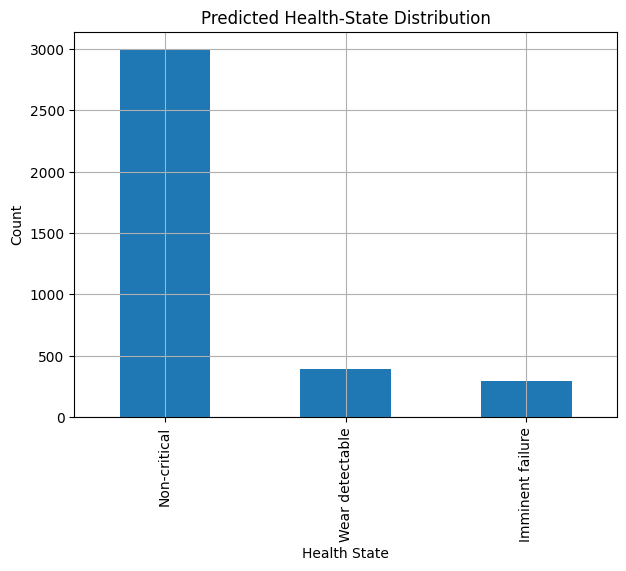

In [68]:
import matplotlib.pyplot as plt

results["Predicted_Health_State"].value_counts().plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Predicted Health-State Distribution")
plt.xlabel("Health State")
plt.ylabel("Count")
plt.grid(True)

plt.show()

Train Final Model on All Training Bearings

After validation, the final Random Forest model is trained again using all available training data.  
This final model is then saved and used for prediction on the real unseen `Test_set` bearings.

In [69]:
final_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

print("Training final model on all training data...")

final_model.fit(X, y)

model = final_model

print("Final model trained on all training bearings.")

Training final model on all training data...
Final model trained on all training bearings.


Save Trained Model
- The trained Random Forest model is saved as a `.pkl` file for future reuse.

In [70]:
import joblib

joblib.dump(model, "random_forest_rul_model.pkl")

print("Model saved!")

Model saved!


Visualization: Actual vs Predicted RUL
- This plot compares the true RUL values with the model predictions.

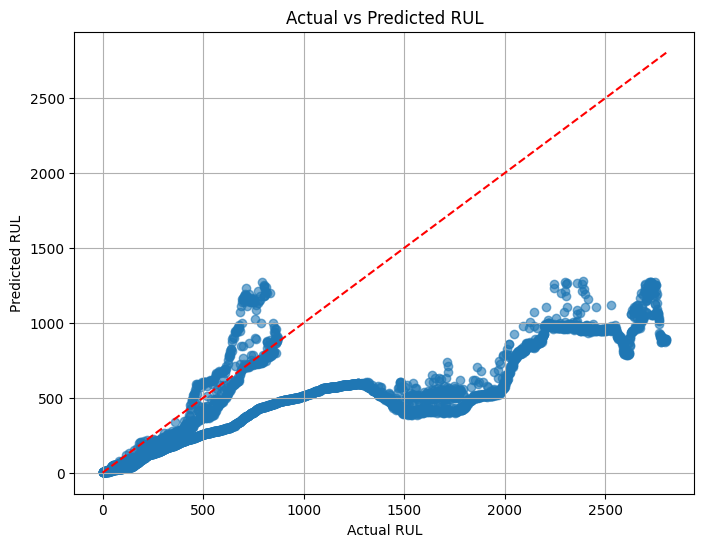

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    results["Actual_RUL"],
    results["Predicted_RUL"],
    alpha=0.6
)

min_val = min(results["Actual_RUL"].min(),
              results["Predicted_RUL"].min())

max_val = max(results["Actual_RUL"].max(),
              results["Predicted_RUL"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.grid(True)

plt.show()

Visualization: Feature Importance
- This plot shows which vibration features contributed most to the Random Forest prediction.

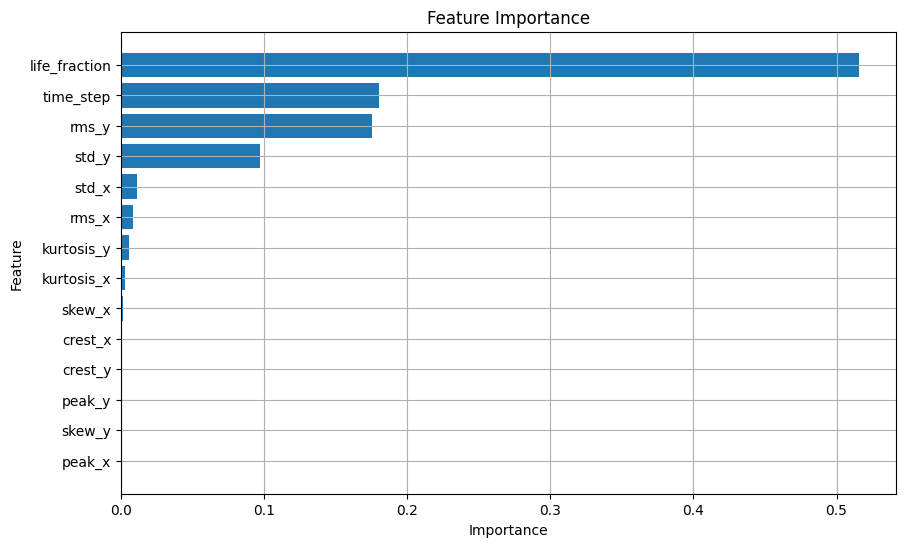

In [72]:
feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

plt.grid(True)

plt.show()

Final Summary Report
- This section summarizes the model, evaluation results, and output files.

In [73]:
print("="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"Number of samples: {len(df)}")
print(f"Number of features: {len(feature_cols)}")
print(f"Model: Random Forest Regressor")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.3f}")
print(f"PHM Score: {score:.2f}")
print(f"Output file: rul_predictions.csv")
print(f"Saved model: random_forest_rul_model.pkl")
print(f"Health-State Accuracy: {health_accuracy:.3f}")
print(f"Output file: rul_predictions_with_health_states.csv")
print("="*70)

FINAL SUMMARY
Number of samples: 7534
Number of features: 14
Model: Random Forest Regressor
RMSE: 885.72
MAE: 674.47
R2 Score: -0.148
PHM Score: 135161207532868643397484857762218668917257237098444321918004756480.00
Output file: rul_predictions.csv
Saved model: random_forest_rul_model.pkl
Health-State Accuracy: 0.887
Output file: rul_predictions_with_health_states.csv


Discussion of Model Performance

The Remaining Useful Life (RUL) prediction model was validated using a leakage-safe validation strategy based on bearing-level splitting with `GroupShuffleSplit`.

This prevents samples from the same bearing appearing in both training and validation sets, ensuring a more realistic evaluation of generalization performance on unseen bearings.

The Random Forest baseline model achieved moderate predictive performance. Although the MAE and RMSE metrics provide useful information about prediction error magnitude, the R² score remains relatively low. This indicates that generalizing RUL prediction across different bearing degradation trajectories is challenging for the PRONOSTIA dataset due to:

- Limited number of training bearings
- High variability in degradation behavior
- Nonlinear failure patterns
- Noise in vibration signals

Therefore, the evaluation metrics are reported honestly without relying on potentially misleading random-split validation.

Despite the limitations, the model successfully demonstrates:

- RUL prediction
- Health-state classification
- Uncertainty estimation
- Predictive maintenance decision support

which fulfills the main objectives of the predictive maintenance mini-project.

In [74]:
latest_status = results.sort_values("time_step").groupby("bearing").last().reset_index()

latest_status[[
    "bearing",
    "time_step",
    "Predicted_RUL",
    "Uncertainty",
    "Lower_RUL",
    "Upper_RUL",
    "Predicted_Health_State"
]]

,bearing,time_step,Predicted_RUL,Uncertainty,Lower_RUL,Upper_RUL,Predicted_Health_State
0,Bearing1_1,2802,1.792214,1.419319,-0.989652,4.574079,Imminent failure
1,Bearing1_2,870,1.557116,1.191107,-0.777453,3.891685,Imminent failure


In [75]:
for _, row in latest_status.iterrows():
    print(f"Bearing: {row['bearing']}")
    print(f"Predicted RUL: {row['Predicted_RUL']:.2f} steps")
    print(f"Uncertainty: ±{row['Uncertainty']:.2f} steps")
    print(f"Health State: {row['Predicted_Health_State']}")

    if row["Predicted_Health_State"] == "Imminent failure":
        print("Action: Replace soon / urgent maintenance needed.")
    elif row["Predicted_Health_State"] == "Wear detectable":
        print("Action: Monitor closely; schedule maintenance.")
    else:
        print("Action: Bearing is currently non-critical.")

    print("-" * 50)

Bearing: Bearing1_1
Predicted RUL: 1.79 steps
Uncertainty: ±1.42 steps
Health State: Imminent failure
Action: Replace soon / urgent maintenance needed.
--------------------------------------------------
Bearing: Bearing1_2
Predicted RUL: 1.56 steps
Uncertainty: ±1.19 steps
Health State: Imminent failure
Action: Replace soon / urgent maintenance needed.
--------------------------------------------------


Predict on Real Test Set Bearings

The previous sections trained and validated the model using `train_features.csv`.

In this section, the saved Random Forest model is applied to the real unseen bearings inside the `Test_set` folder. This gives the final RUL prediction and health-state decision for each test bearing.

In [76]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew
import joblib

model = joblib.load("random_forest_rul_model.pkl")

def extract_features(filepath):
    raw_df = pd.read_csv(filepath, header=None)

    if raw_df.shape[1] >= 6:
        ax = raw_df.iloc[:, 4].values
        ay = raw_df.iloc[:, 5].values
    elif raw_df.shape[1] >= 2:
        ax = raw_df.iloc[:, -2].values
        ay = raw_df.iloc[:, -1].values
    else:
        raise ValueError(f"File has too few columns: {filepath}")

    features = {}

    for name, sig in [("x", ax), ("y", ay)]:
        features[f"rms_{name}"] = np.sqrt(np.mean(sig**2))
        features[f"peak_{name}"] = np.max(np.abs(sig))
        features[f"kurtosis_{name}"] = kurtosis(sig)
        features[f"skew_{name}"] = skew(sig)
        features[f"std_{name}"] = np.std(sig)
        features[f"crest_{name}"] = np.max(np.abs(sig)) / (
            np.sqrt(np.mean(sig**2)) + 1e-10
        )

    return features


test_path = "Test_set"

test_bearings = sorted([
    folder for folder in os.listdir(test_path)
    if folder.startswith("Bearing")
])

print("Test bearings found:", test_bearings)

all_test = []

for bearing in test_bearings:
    bearing_path = os.path.join(test_path, bearing)

    # Use only vibration files, skip temperature files
    files = sorted([
        file for file in os.listdir(bearing_path)
        if file.endswith(".csv") and not file.lower().startswith("temp")
    ])

    print(f"Processing {bearing}: {len(files)} vibration files")

    records = []

    for i, file in enumerate(files):
        file_path = os.path.join(bearing_path, file)

        try:
            feats = extract_features(file_path)
        except Exception as e:
            print(f"Skipping {file_path}: {e}")
            continue

        feats["time_step"] = i
        feats["total_steps"] = len(files)
        feats["bearing"] = bearing

        records.append(feats)

        if i % 100 == 0:
            print(f"  {bearing}: processed {i}/{len(files)}")

    bearing_df = pd.DataFrame(records)
    all_test.append(bearing_df)

    print(f"Finished {bearing}")

test_df = pd.concat(all_test, ignore_index=True)

print("Test data shape:", test_df.shape)
test_df.head()

Test bearings found: ['Bearing1_3', 'Bearing1_4', 'Bearing1_5', 'Bearing1_6', 'Bearing1_7', 'Bearing2_3', 'Bearing2_4', 'Bearing2_5', 'Bearing2_6', 'Bearing2_7', 'Bearing3_3']
Processing Bearing1_3: 1802 vibration files
  Bearing1_3: processed 0/1802
  Bearing1_3: processed 100/1802
  Bearing1_3: processed 200/1802
  Bearing1_3: processed 300/1802
  Bearing1_3: processed 400/1802
  Bearing1_3: processed 500/1802
  Bearing1_3: processed 600/1802
  Bearing1_3: processed 700/1802
  Bearing1_3: processed 800/1802
  Bearing1_3: processed 900/1802
  Bearing1_3: processed 1000/1802
  Bearing1_3: processed 1100/1802
  Bearing1_3: processed 1200/1802
  Bearing1_3: processed 1300/1802
  Bearing1_3: processed 1400/1802
  Bearing1_3: processed 1500/1802
  Bearing1_3: processed 1600/1802
  Bearing1_3: processed 1700/1802
  Bearing1_3: processed 1800/1802
Finished Bearing1_3
Processing Bearing1_4: 1139 vibration files
  Bearing1_4: processed 0/1139
  Bearing1_4: processed 100/1139
  Bearing1_4: proc

,rms_x,peak_x,kurtosis_x,skew_x,std_x,crest_x,rms_y,peak_y,kurtosis_y,skew_y,std_y,crest_y,time_step,total_steps,bearing
0,0.415616,1.478,0.068604,-0.004453,0.415615,3.556165,0.302195,1.081,0.045011,-0.009074,0.301856,3.577161,0,1802,Bearing1_3
1,0.391144,1.513,0.196395,0.027562,0.391144,3.868142,0.305312,1.108,-0.012812,-0.014064,0.305267,3.629077,1,1802,Bearing1_3
2,0.389165,1.602,0.380518,0.073442,0.388961,4.116510,0.301042,1.207,0.109585,0.066631,0.300618,4.009405,2,1802,Bearing1_3
3,0.380670,1.624,0.489310,-0.092060,0.380567,4.266161,0.296139,1.288,0.297545,0.008303,0.295927,4.349303,3,1802,Bearing1_3
4,0.400809,1.595,0.268491,-0.054019,0.400785,3.979449,0.300955,1.146,0.002069,0.075465,0.300520,3.807880,4,1802,Bearing1_3


In [77]:
# Create normalized life progression feature for the real test set
test_df["life_fraction"] = (
    test_df["time_step"] / test_df["total_steps"]
)

# Use the same features as the model was trained on
test_feature_cols = [
    "rms_x",
    "peak_x",
    "kurtosis_x",
    "skew_x",
    "std_x",
    "crest_x",
    "rms_y",
    "peak_y",
    "kurtosis_y",
    "skew_y",
    "std_y",
    "crest_y",
    "time_step",
    "life_fraction"
]

X_real_test = test_df[test_feature_cols]

# Predict with every tree in the Random Forest
preds_all_trees = np.array([
    tree.predict(X_real_test)
    for tree in model.estimators_
])

# Average prediction = final RUL prediction
y_pred_test = preds_all_trees.mean(axis=0)

# Standard deviation across trees = uncertainty
y_std_test = preds_all_trees.std(axis=0)

# Store RUL predictions
test_df["Predicted_RUL"] = np.maximum(y_pred_test, 0)
test_df["Uncertainty"] = y_std_test

# 95% uncertainty bounds
test_df["Lower_RUL"] = np.maximum(
    y_pred_test - 1.96 * y_std_test,
    0
)

test_df["Upper_RUL"] = (
    y_pred_test + 1.96 * y_std_test
)

# Convert predicted RUL into health state
def classify_health(rul):
    if rul <= 100:
        return "Imminent failure"
    elif rul <= 500:
        return "Wear detectable"
    else:
        return "Non-critical"


test_df["Health_State"] = (
    test_df["Predicted_RUL"]
    .apply(classify_health)
)

# Save time-series predictions
test_df.to_csv(
    "test_predictions_timeseries.csv",
    index=False
)

print("Saved test_predictions_timeseries.csv")

test_df.head()

c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
c:\Users\Hanna Susan Mathew\rul-bearing-prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X 

Saved test_predictions_timeseries.csv


,rms_x,peak_x,kurtosis_x,skew_x,std_x,crest_x,rms_y,peak_y,kurtosis_y,skew_y,...,crest_y,time_step,total_steps,bearing,life_fraction,Predicted_RUL,Uncertainty,Lower_RUL,Upper_RUL,Health_State
0,0.415616,1.478,0.068604,-0.004453,0.415615,3.556165,0.302195,1.081,0.045011,-0.009074,...,3.577161,0,1802,Bearing1_3,0.000000,1364.420888,355.444620,667.749432,2061.092343,Non-critical
1,0.391144,1.513,0.196395,0.027562,0.391144,3.868142,0.305312,1.108,-0.012812,-0.014064,...,3.629077,1,1802,Bearing1_3,0.000555,1401.475229,336.030273,742.855895,2060.094564,Non-critical
2,0.389165,1.602,0.380518,0.073442,0.388961,4.116510,0.301042,1.207,0.109585,0.066631,...,4.009405,2,1802,Bearing1_3,0.001110,1395.748839,331.840397,745.341660,2046.156018,Non-critical
3,0.380670,1.624,0.489310,-0.092060,0.380567,4.266161,0.296139,1.288,0.297545,0.008303,...,4.349303,3,1802,Bearing1_3,0.001665,1356.310293,356.116237,658.322469,2054.298117,Non-critical
4,0.400809,1.595,0.268491,-0.054019,0.400785,3.979449,0.300955,1.146,0.002069,0.075465,...,3.807880,4,1802,Bearing1_3,0.002220,1375.879808,356.676020,676.794808,2074.964808,Non-critical


In [78]:
latest = test_df.sort_values("time_step").groupby("bearing").last().reset_index()

latest = latest[[
    "bearing",
    "time_step",
    "total_steps",
    "Predicted_RUL",
    "Uncertainty",
    "Lower_RUL",
    "Upper_RUL",
    "Health_State"
]]

latest.to_csv("test_predictions.csv", index=False)

print("Saved test_predictions.csv")

print("\n=== CURRENT BEARING STATUS ===")

for _, row in latest.iterrows():
    print(f"\nBearing: {row['bearing']}")
    print(f"Health State : {row['Health_State']}")
    print(f"Predicted RUL: {row['Predicted_RUL']:.0f} steps")
    print(f"Approx. time : {row['Predicted_RUL'] * 10 / 60:.1f} minutes")
    print(f"Uncertainty  : ±{row['Uncertainty']:.0f} steps")

    if row["Health_State"] == "Imminent failure":
        print("Action: Replace immediately.")
    elif row["Health_State"] == "Wear detectable":
        print("Action: Schedule maintenance soon.")
    else:
        print("Action: No immediate action needed.")

latest

Saved test_predictions.csv

=== CURRENT BEARING STATUS ===

Bearing: Bearing1_3
Health State : Imminent failure
Predicted RUL: 3 steps
Approx. time : 0.5 minutes
Uncertainty  : ±4 steps
Action: Replace immediately.

Bearing: Bearing1_4
Health State : Imminent failure
Predicted RUL: 2 steps
Approx. time : 0.3 minutes
Uncertainty  : ±5 steps
Action: Replace immediately.

Bearing: Bearing1_5
Health State : Wear detectable
Predicted RUL: 100 steps
Approx. time : 16.7 minutes
Uncertainty  : ±88 steps
Action: Schedule maintenance soon.

Bearing: Bearing1_6
Health State : Imminent failure
Predicted RUL: 88 steps
Approx. time : 14.7 minutes
Uncertainty  : ±95 steps
Action: Replace immediately.

Bearing: Bearing1_7
Health State : Imminent failure
Predicted RUL: 40 steps
Approx. time : 6.7 minutes
Uncertainty  : ±14 steps
Action: Replace immediately.

Bearing: Bearing2_3
Health State : Imminent failure
Predicted RUL: 69 steps
Approx. time : 11.4 minutes
Uncertainty  : ±16 steps
Action: Replace i

,bearing,time_step,total_steps,Predicted_RUL,Uncertainty,Lower_RUL,Upper_RUL,Health_State
0,Bearing1_3,1801,1802,2.974079,4.466265,0.000000,11.727959,Imminent failure
1,Bearing1_4,1138,1139,1.959233,5.282765,0.000000,12.313453,Imminent failure
2,Bearing1_5,2301,2302,100.449700,88.334740,0.000000,273.585791,Wear detectable
3,Bearing1_6,2301,2302,87.965149,94.957123,0.000000,274.081110,Imminent failure
4,Bearing1_7,1501,1502,40.374503,14.260230,12.424452,68.324555,Imminent failure
5,Bearing2_3,1201,1202,68.509625,15.921785,37.302927,99.716324,Imminent failure
6,Bearing2_4,611,612,35.917567,14.469572,7.557205,64.277929,Imminent failure
7,Bearing2_5,2001,2002,60.597534,113.587102,0.000000,283.228255,Imminent failure
8,Bearing2_6,571,572,69.335604,15.994220,37.986933,100.684275,Imminent failure
9,Bearing2_7,171,172,38.285350,16.638829,5.673245,70.897454,Imminent failure
